In [6]:
import importlib
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))
import src.meta_processing as mp
import pandas as pd

gene_expr = pd.read_csv("../data/processed/gene_expression.csv",index_col=0,header=0)
meta = pd.read_csv("../data/processed/metadata.csv", usecols=["id", "WHO grade","Primary/Recurrent"]).set_index("id")
importlib.reload(mp)

#Total
typeIII = mp.typeIII
typeIV = mp.typeIV

#Primary and recurrent
III_primary = mp.III_primary
III_recurrent = (mp.III_recurrent)
IV_primary = (mp.IV_primary)
IV_recurrent = (mp.IV_recurrent)

#III sub
III_prim_PN = (mp.III_prim_PN)
III_prim_Mes = (mp.III_prim_Mes)
III_prim_Prolif = (mp.III_prim_Prolif)

III_rec_PN = (mp.III_rec_PN)
III_rec_Mes = (mp.III_rec_Mes)
III_rec_Prolif = (mp.III_rec_Prolif)


#IV sub
IV_prim_PN = (mp.IV_prim_PN)
IV_prim_Mes = (mp.IV_prim_Mes)
IV_prim_Prolif = (mp.IV_prim_Prolif)

IV_rec_PN = (mp.IV_rec_PN)
IV_rec_Mes = (mp.IV_rec_Mes)
IV_prec_Prolif = (mp.IV_rec_Prolif)

Number of primary type III samples: 21
Number of recurrent type III samples: 3
Number of primary type IV samples: 56
Number of recurrent type IV samples: 20


PRIMARY III
PN: 20
Mes: 1
Prolif: 0


RECURRENT III
PN: 2
Mes: 1
Prolif: 0


PRIMARY IV
PN: 10
Mes: 22
Prolif: 24


RECURRENT IV
PN: 5
Mes: 11
Prolif: 4


# Perform PCA for III and IV

In [3]:
# Cell 1 — prepare labels and align with expression matrix
labels = (
    meta.set_index("id")["WHO grade"]
    .astype(str)
    .str.extract(r"\b(III|IV)\b", expand=False)
)
labels.index = labels.index.astype(str)

X = gene_expr.T.copy()
X.index = X.index.astype(str)

# keep only shared sample IDs and drop missing labels
common_ids = X.index.intersection(labels.index)
X = X.loc[common_ids]
labels = labels.loc[common_ids]
keep = labels.notna()
X = X.loc[keep]
labels = labels.loc[keep]

print("X shape:", X.shape)
print("labels shape:", labels.shape)
print("aligned:", (X.index == labels.index).all())
print(labels.value_counts())

X shape: (100, 21290)
labels shape: (100,)
aligned: True
WHO grade
IV     76
III    24
Name: count, dtype: int64


Gene Symbol,A1BG,A1BG-AS1,A1CF,A2M,A2MP1,A4GALT,A4GNT,AA06,AAAS,AACS,...,ZYX,ZZEF1,ZZZ3,abParts,av27s1,hADV36S1,hsa-let-7a-3,hsa-let-7b,hsa-mir-4763,mir-223
3744,9.831141,4.554444,7.875861,11.734165,9.544802,6.919718,7.047503,8.178483,7.844467,8.624053,...,9.612188,8.400255,10.967641,9.020134,6.475996,6.707530,7.335774,7.335774,7.335774,4.045012
3745,6.713603,3.878012,8.387857,11.605659,9.544469,5.407356,7.107997,8.692278,7.588122,8.598475,...,11.132588,7.663758,10.396707,4.576102,6.769839,5.457092,9.760798,9.760798,9.760798,4.666265
3746,8.566009,5.055107,8.252021,11.884063,9.169322,4.882654,7.034788,8.484363,7.633073,8.271772,...,11.060741,8.722946,10.754241,3.594534,7.265899,5.803246,8.445602,8.445602,8.445602,3.981645
3747,7.603816,5.188342,7.839427,11.239311,8.460019,5.262341,7.149580,7.916660,8.001140,8.602996,...,9.936910,9.055401,10.181479,3.899669,5.247267,6.096708,9.882493,9.882493,9.882493,4.130311
3748,8.923892,4.686629,8.111663,12.615322,9.027937,6.812407,7.423595,7.342187,8.466311,8.078567,...,11.198753,8.364291,9.929704,4.915355,3.926472,5.925088,8.807120,8.807120,8.807120,3.174062
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4793,8.251793,5.851187,8.432633,12.099056,8.689099,4.840029,6.910971,8.261627,5.825875,7.731412,...,8.908923,8.713573,10.105190,5.095715,6.069452,5.958367,8.758109,8.758109,8.758109,5.354990
5063,8.000203,5.192012,9.093823,11.788088,8.185404,6.290839,8.026947,8.604059,6.968098,9.348609,...,9.326661,8.712839,9.902250,6.370331,6.599824,5.992500,5.654549,5.654549,5.654549,3.940005
5070,8.803328,5.294473,8.968273,11.665590,8.767908,5.194026,7.944256,8.004888,7.426617,8.589434,...,9.579802,8.662196,10.137050,5.779075,5.499470,5.560632,8.070507,8.070507,8.070507,3.272682
9907,6.878393,5.074784,8.623266,11.884063,9.023691,5.406398,8.018705,8.335471,6.241782,9.011193,...,8.923056,8.329337,10.485157,4.487422,6.505612,4.587097,8.365020,8.365020,8.365020,3.476665


In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)

# PCA scatter with blue/red for III/IV
color_map = {"III": "blue", "IV": "red"}


Explained variance ratio: [0.09251799 0.06970306]


# Note: No control, just relative to each other

# Volcano plot

In [23]:
# Volcano plot for log2-normalized X (no log ratio needed)
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt

# optional FDR correction
try:
    from statsmodels.stats.multitest import multipletests
    _have_multipletests = True
except Exception:
    _have_multipletests = False

groupA, groupB = "III", "IV"
idxA = (labels == groupA)
idxB = (labels == groupB)

X_A = X.loc[idxA]
X_B = X.loc[idxB]

# log2 fold-change as difference of means (since X is log2)
meanA = X_A.mean(axis=0)
meanB = X_B.mean(axis=0)
log2fc = meanB - meanA

# gene-wise t-test (Welch)
pvals = X.apply(lambda col: ttest_ind(col[idxB], col[idxA], equal_var=False, nan_policy="omit").pvalue, axis=0)

# adjust p-values (Benjamini-Hochberg) if available
if _have_multipletests:
    _, p_adj, _, _ = multipletests(pvals, alpha=0.05, method="fdr_bh")
    p_adj = pd.Series(p_adj, index=pvals.index)
else:
    p_adj = pvals.copy()

neg_log10_p = -np.log10(p_adj + 1e-300)

volcano = pd.DataFrame({
    "log2FC": log2fc,
    "pval": pvals,
    "p_adj": p_adj,
    "neg_log10_p": neg_log10_p
})


# thresholds
fc_thresh = 1.0
p_thresh = 0.05
sig_mask = (volcano["p_adj"] < p_thresh) & (volcano["log2FC"].abs() >= fc_thresh)

# colors: significant down = green, significant up = blue, non-significant = lightgray
colors = np.where(sig_mask, np.where(volcano["log2FC"] < 0, "green", "blue"), "lightgray")


# annotate top significant hits only
top_hits = volcano.loc[sig_mask].sort_values("p_adj").head(20)




In [24]:
# Boxplots and heatmap selecting top genes from `volcano` (no external top_genes variable)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# choose how many top genes to show
top_n = 20

# ensure `volcano`, `X`, `labels` exist and are aligned
if "volcano" not in globals():
    raise RuntimeError("`volcano` not found — run the volcano cell first")

# pick only genes that meet both thresholds, then top by adjusted p-value
pcol = "p_adj" if "p_adj" in volcano.columns else "pval"
sig_genes = volcano.loc[sig_mask]
if sig_genes.empty:
    raise RuntimeError("No genes meet the thresholds. Lower thresholds or check data.")
top_genes = sig_genes.sort_values(pcol).index[:top_n].tolist()

# Boxplot
labels.name = "WHO"
df_bp = X[top_genes].join(labels).reset_index().melt(id_vars=["index", "WHO"],
                                                     var_name="gene",
                                                     value_name="expr")


C:\Users\haina\AppData\Local\Temp\ipykernel_22764\2959431797.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


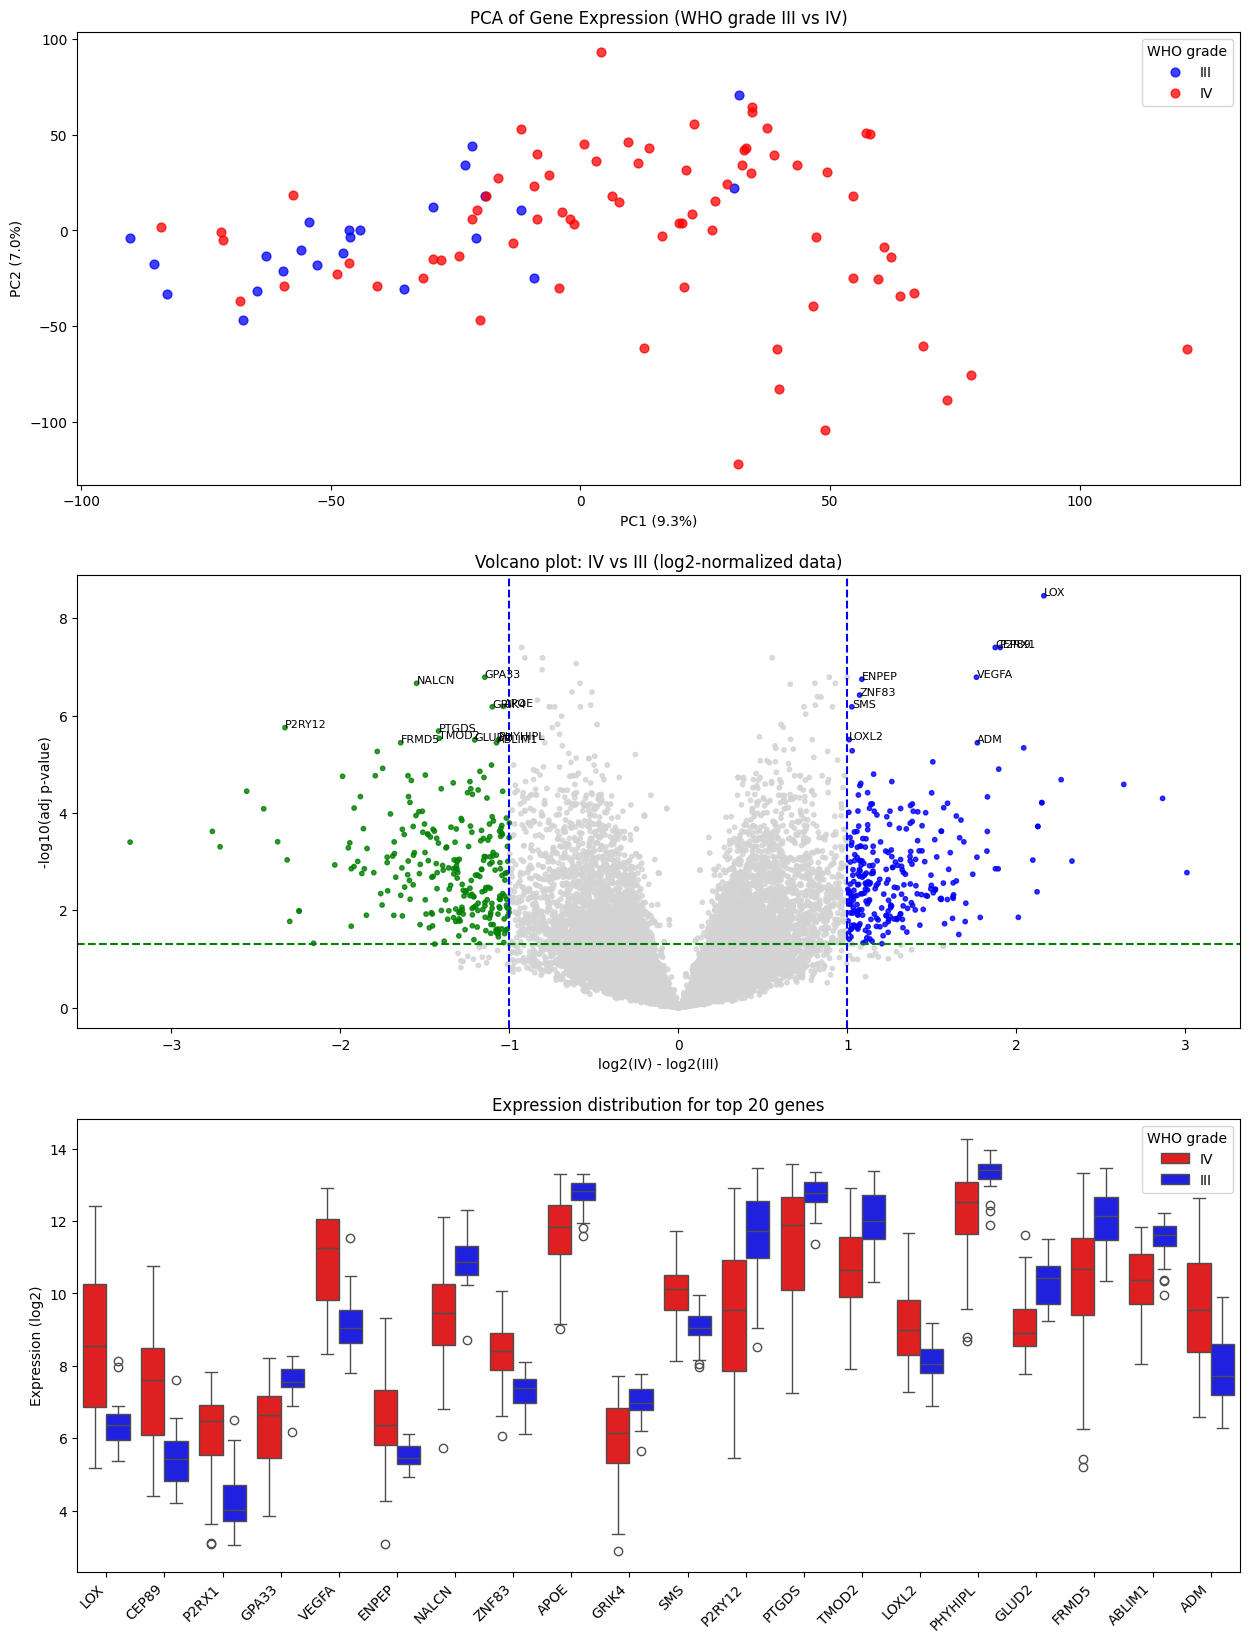

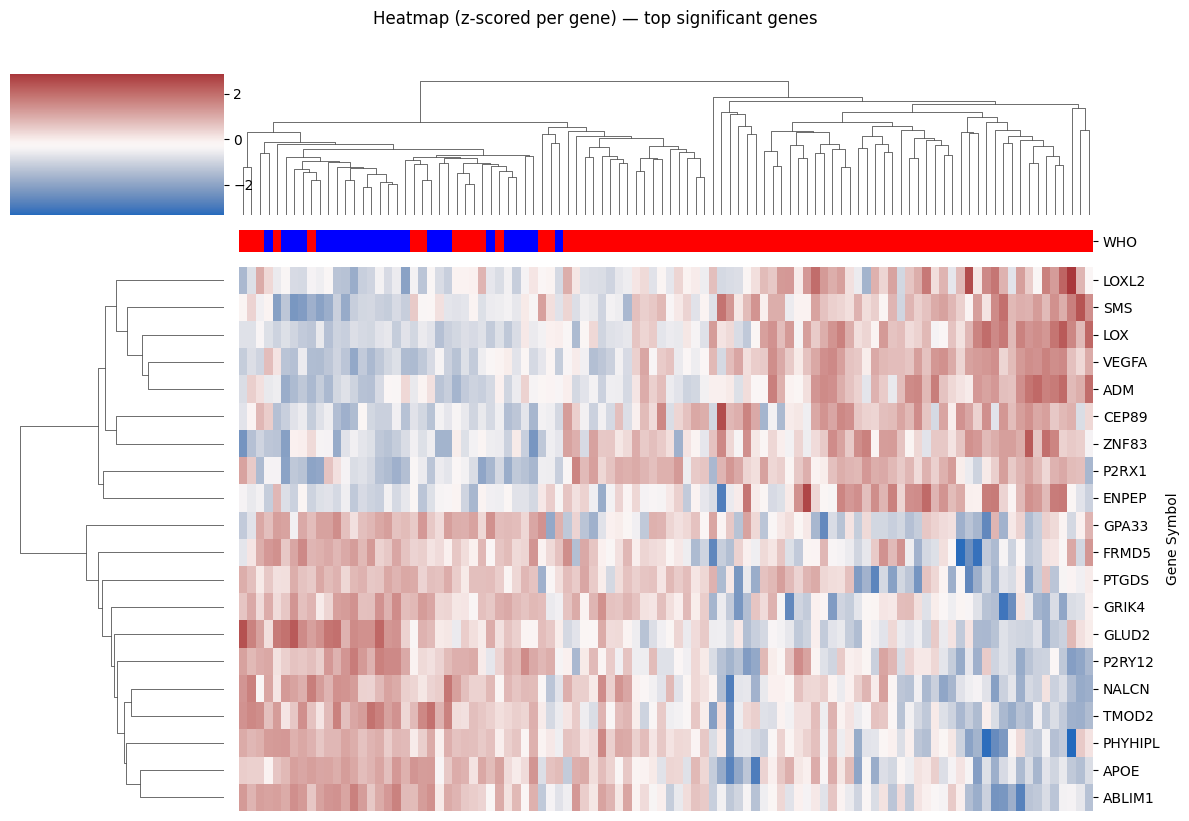

In [28]:
# Combine PCA, volcano, boxplot, and heatmap into a single 2x2 figure
fig, axes = plt.subplots(3, 1, figsize=(15, 20))

# --- PCA plot 
ax = axes[0]
for t in sorted(labels.unique()):
    mask = (labels == t).to_numpy()
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=t, color=color_map.get(t, "gray"), alpha=0.75, s=40)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("PCA of Gene Expression (WHO grade III vs IV)")
ax.legend(title="WHO grade")

# --- Volcano plot 
ax = axes[1]
colors = np.where(sig_mask, np.where(volcano["log2FC"] < 0, "green", "blue"), "lightgray")
ax.scatter(volcano["log2FC"], volcano["neg_log10_p"], c=colors, s=10, alpha=0.8)
ax.axvline(fc_thresh, color="blue", linestyle="--")
ax.axvline(-fc_thresh, color="blue", linestyle="--")
ax.axhline(-np.log10(p_thresh), color="green", linestyle="--")
ax.set_xlabel("log2(IV) - log2(III)")
ax.set_ylabel("-log10(adj p-value)")
ax.set_title("Volcano plot: IV vs III (log2-normalized data)")
# Annotate top significant hits only
top_hits = volcano.loc[sig_mask].sort_values("p_adj").head(20)
for gene, row in top_hits.iterrows():
    ax.text(row["log2FC"], row["neg_log10_p"], gene, fontsize=8)

# --- Boxplot
ax = axes[2]
sns.boxplot(x="gene", y="expr", hue="WHO", data=df_bp, order=top_genes, palette={"III":"blue","IV":"red"}, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_xlabel("")
ax.set_ylabel("Expression (log2)")
ax.set_title(f"Expression distribution for top {len(top_genes)} genes")
ax.legend(title="WHO grade")

# --- Heatmap 
data_heat = X[top_genes].T  # genes x samples
data_z = data_heat.subtract(data_heat.mean(axis=1), axis=0).div(data_heat.std(axis=1).replace(0,1), axis=0)

col_colors = labels.map({"III":"blue","IV":"red"}).loc[data_z.columns]

sns.clustermap(data_z, col_colors=col_colors, cmap="vlag", figsize=(12,8),
               xticklabels=False, yticklabels=True)
plt.suptitle("Heatmap (z-scored per gene) — top significant genes", y=1.02)

plt.tight_layout()
plt.show()